# DAMICORE: categorias de abuso

## Proposta de pesquisa

**Pergunta:** as categorias da fonte relacionadas à violência contra mulheres apresentam perfis contextuais recorrentes?

**Unidade de análise:** uma categoria da fonte, não uma pessoa ou uma denúncia. Todas as denúncias com vítima feminina entre janeiro de 2020 e junho de 2026 contribuem para o perfil agregado de cada categoria elegível em que aparecem.

**Escopo operacional:** categorias sob `INTEGRIDADE`, `VIDA` ou `VIOLÊNCIA INSTITUCIONAL`, além de `LIBERDADE > SEXUAL` e da categoria da fonte sobre violência política de gênero. Essa regra da taxonomia da fonte é exploratória, não uma definição jurídica de violência contra a mulher. O primeiro semestre de 2020 preserva rótulos legados sem a hierarquia `>`; esses rótulos ficam fora do subconjunto comparável até uma harmonização específica.

**Representação:** todas as categorias recebem o mesmo vocabulário ordenado de contextos: idade, relação, ambiente, mês, canal de atendimento, tipo de denunciante, frequência, situação de emergência, grupo vulnerável, deficiência da vítima, gênero do suspeito e natureza jurídica do suspeito. Cada valor é serializado como desvio relativo à distribuição global, em largura fixa de `00000` a `10000`; zero relativo significa exatamente a prevalência global. O suporte total da categoria fica fora do documento comprimido.

**Hipótese exploratória:** categorias com desvios relativos semelhantes de idade, relação, ambiente, processo de registro e mês terão menores distâncias NCD, aparecerão próximas na árvore DAMICORE e tenderão a compartilhar um cluster.

A cadeia do experimento é: `desvio contextual relativo → matriz de distâncias NCD → diagnóstico de viés → árvore → clusters DAMICORE → grafos NetworkX`. A proposta é uma comparação exploratória de perfis contextuais; ela não confirma tipologias jurídicas.


In [1]:
from datetime import datetime
from pathlib import Path
from io import StringIO
from itertools import combinations
from math import ceil, cos, log10, log2, pi, sin, sqrt
import os
import textwrap

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
import networkx as nx
import pandas as pd
import psycopg
from Bio import Phylo
from damicore import estimate, run
from dotenv import load_dotenv
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Execute este notebook a partir da raiz do repositório ou do diretório notebooks.")

load_dotenv(PROJECT_ROOT / ".env")
DATABASE_URL = os.getenv("DISQUE100_DATABASE_URL", "postgresql://postgres@127.0.0.1:5433/disque100")
START_DATE = "2020-01-01"
END_DATE = "2026-07-01"
VICTIM_GENDER = "FEMININO"
MIN_REPORT_COUNT = 50
SMOOTHING_ALPHA = 20
LOG_RATIO_LIMIT = 4.0
BIAS_WARNING_THRESHOLD = 0.70

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "damicore_abuse_categories_2020_2026"
WORK_DIR = ARTIFACT_DIR / "work"
CORPUS_DIR = WORK_DIR / "normalized-corpus"
RESULTS_DIR = ARTIFACT_DIR / "results"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def wrapped_label(text, width=30):
    return '\n'.join(textwrap.wrap(text, width=width))

VISUAL_STYLE = {
    'edge_color_sim': '#87979B',
    'edge_color_cluster': '#AAB5B8',
    'font_size': 7,
    'node_border_color': '#263238',
    'border_width': 1.0,
}


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cobertura, escopo e contextos agregados

`source_hash` é usado somente dentro do PostgreSQL para contar denúncias distintas. O notebook recebe totais de cobertura e contagens agregadas, nunca denúncias individuais. Valores ausentes de idade, relação, ambiente e das novas dimensões recebem `DESCONHECIDO` para que toda denúncia permaneça representada.


In [2]:
category_sql = '''
nullif(concat_ws(' > ',
    nullif(trim(split_part(violation, '>', 1)), ''),
    nullif(trim(split_part(violation, '>', 2)), '')
), '')
'''

coverage_query = f'''
WITH reports AS (
    SELECT source_hash,
           bool_or(violation IS NOT NULL) AS has_violation,
           bool_or(({category_sql}) IS NOT NULL) AS has_category
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
    GROUP BY source_hash
)
SELECT count(*) AS female_reports,
       count(*) FILTER (WHERE has_category) AS reports_with_category,
       count(*) FILTER (WHERE NOT has_violation) AS reports_without_violation
FROM reports
'''

context_query = f'''
WITH report_values AS (
    SELECT DISTINCT
        source_hash,
        {category_sql} AS category,
        coalesce(victim_age_group, 'DESCONHECIDO') AS age_group,
        coalesce(victim_suspect_relationship, 'DESCONHECIDO') AS relationship,
        coalesce(violation_setting, 'DESCONHECIDO') AS setting,
        to_char(date_trunc('month', registered_at), 'YYYY-MM') AS month,
        coalesce(service_channel, 'DESCONHECIDO') AS service_channel,
        coalesce(reporter_type, 'DESCONHECIDO') AS reporter_type,
        coalesce(frequency, 'DESCONHECIDO') AS frequency,
        coalesce(emergency_status, 'DESCONHECIDO') AS emergency_status,
        coalesce(vulnerable_group, 'DESCONHECIDO') AS vulnerable_group,
        coalesce(victim_disability, 'DESCONHECIDO') AS victim_disability,
        coalesce(suspect_gender, 'DESCONHECIDO') AS suspect_gender,
        coalesce(suspect_legal_nature, 'DESCONHECIDO') AS suspect_legal_nature
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
), contexts AS (
    SELECT category, source_hash, 'denuncia'::text AS dimension, 'TODAS'::text AS value
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'faixa_etaria', age_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'relacao_vitima_suspeito', relationship
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'ambiente', setting
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'mes', month
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'canal_atendimento', service_channel
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'tipo_denunciante', reporter_type
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'frequencia', frequency
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'situacao_emergencia', emergency_status
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'grupo_vulneravel', vulnerable_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'deficiencia_vitima', victim_disability
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'genero_suspeito', suspect_gender
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'natureza_juridica_suspeito', suspect_legal_nature
    FROM report_values WHERE category IS NOT NULL
)
SELECT category, dimension, value, count(DISTINCT source_hash) AS report_count
FROM contexts
GROUP BY category, dimension, value
ORDER BY category, dimension, value
'''

parameters = (START_DATE, END_DATE, VICTIM_GENDER)
with psycopg.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute(coverage_query, parameters)
        coverage = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])
        cursor.execute(context_query, parameters)
        context_counts = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])

display(coverage.rename(columns={
    "female_reports": "Denúncias com vítima feminina",
    "reports_with_category": "Denúncias com categoria",
    "reports_without_violation": "Denúncias sem violação",
}))
category_support = (
    context_counts.loc[context_counts["dimension"] == "denuncia", ["category", "report_count"]]
    .rename(columns={"report_count": "category_report_count"})
    .sort_values("category")
)

scope_mask = (
    category_support["category"].str.startswith(("INTEGRIDADE", "VIDA", "VIOLÊNCIA INSTITUCIONAL"))
    | category_support["category"].eq("LIBERDADE > SEXUAL")
    | category_support["category"].str.contains(
        "VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES", regex=False
    )
)
category_support["status"] = "incluída"
category_support.loc[~scope_mask, "status"] = "fora do escopo operacional"
category_support.loc[
    scope_mask & (category_support["category_report_count"] < MIN_REPORT_COUNT), "status"
] = "abaixo do suporte mínimo"

included_support = category_support.loc[category_support["status"] == "incluída"].copy()
excluded_categories = category_support.loc[category_support["status"] != "incluída"].copy()
included_categories = included_support["category"].tolist()

print(f"Categorias da fonte: {len(category_support)}")
print(f"Categorias incluídas no DAMICORE: {len(included_support)}")
print(f"Suporte mínimo: {MIN_REPORT_COUNT} denúncias distintas")
display(included_support)
display(excluded_categories)


,Denúncias com vítima feminina,Denúncias com categoria,Denúncias sem violação
0,1421122,1420747,0


Categorias da fonte: 34291
Categorias incluídas no DAMICORE: 14
Suporte mínimo: 50 denúncias distintas


,category,category_report_count,status
1838,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,247,incluída
6310,INTEGRIDADE > FÍSICA,1100754,incluída
6611,INTEGRIDADE > NEGLIGÊNCIA,835748,incluída
6867,INTEGRIDADE > PATRIMONIAL,200197,incluída
7179,INTEGRIDADE > PSÍQUICA,1121598,incluída
8609,LIBERDADE > SEXUAL,147380,incluída
10040,VIDA > ABORTO,393,incluída
10239,VIDA > AUTOMUTILAÇAO,1322,incluída
10462,VIDA > FEMINICÍDIO,343,incluída
10702,VIDA > HOMICÍDIO,1517,incluída


,category,category_report_count,status
53,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,2486,fora do escopo operacional
305,DIREITOS CIVIS E POLÍTICOS > CULTURAL,158,fora do escopo operacional
508,DIREITOS CIVIS E POLÍTICOS > LIVRE EXERCÍCIO D...,5056,fora do escopo operacional
765,DIREITOS CIVIS E POLÍTICOS > MEMÓRIA E VERDADE,364,fora do escopo operacional
954,DIREITOS CIVIS E POLÍTICOS > NACIONALIDADE,74,fora do escopo operacional
...,...,...,...
499053,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,1,fora do escopo operacional
499066,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,1,fora do escopo operacional
499080,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,2,fora do escopo operacional
499098,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,1,fora do escopo operacional


## 2. Documento normalizado de largura fixa por categoria elegível

O total da categoria é usado como denominador. Para reduzir o ruído de categorias raras, usamos suavização empírica com `alpha=20`: `(contagem + alpha * prevalência_global) / (suporte + alpha)`. Em seguida, calculamos `log2(prevalência_suavizada / prevalência_global)`. Assim, zero representa o padrão global, valores positivos indicam sobre-representação e valores negativos indicam sub-representação. O resultado é codificado em largura fixa (`00000` a `10000`) para todas as categorias.


In [3]:
for old_file in CORPUS_DIR.glob("*.txt"):
    old_file.unlink()

profile_counts = context_counts.loc[
    context_counts["category"].isin(included_categories)
    & context_counts["dimension"].ne("denuncia")
].copy()
vocabulary = (
    profile_counts[["dimension", "value"]]
    .drop_duplicates()
    .sort_values(["dimension", "value"])
)

normalized_profiles = (
    included_support[["category", "category_report_count"]]
    .merge(vocabulary, how="cross")
    .merge(profile_counts, on=["category", "dimension", "value"], how="left")
    .sort_values(["category", "dimension", "value"])
)
assert normalized_profiles.groupby("category").size().nunique() == 1
normalized_profiles["report_count"] = normalized_profiles["report_count"].fillna(0).astype(int)
global_counts = (
    profile_counts.groupby(["dimension", "value"], as_index=False)["report_count"]
    .sum()
    .rename(columns={"report_count": "global_count"})
)
global_counts["global_prevalence"] = (
    global_counts["global_count"]
    / global_counts.groupby("dimension")["global_count"].transform("sum")
)
normalized_profiles = normalized_profiles.merge(
    global_counts[["dimension", "value", "global_prevalence"]],
    on=["dimension", "value"],
    how="left",
    validate="many_to_one",
)
normalized_profiles["smoothed_prevalence"] = (
    normalized_profiles["report_count"]
    + SMOOTHING_ALPHA * normalized_profiles["global_prevalence"]
) / (normalized_profiles["category_report_count"] + SMOOTHING_ALPHA)
normalized_profiles["relative_log2"] = (
    normalized_profiles["smoothed_prevalence"]
    / normalized_profiles["global_prevalence"]
).map(log2)
normalized_profiles["relative_bps"] = (
    10_000
    * (normalized_profiles["relative_log2"].clip(-LOG_RATIO_LIMIT, LOG_RATIO_LIMIT) + LOG_RATIO_LIMIT)
    / (2 * LOG_RATIO_LIMIT)
).round().astype(int)

category_rows = []
for number, category in enumerate(sorted(included_categories), start=1):
    label = f"category-{number:03d}.txt"
    rows = normalized_profiles.loc[normalized_profiles["category"] == category]
    lines = [
        f"{row.dimension}|{row.value}|{row.relative_bps:05d}"
        for row in rows.itertuples(index=False)
    ]
    (CORPUS_DIR / label).write_text("\n".join(lines) + "\n", encoding="utf-8")
    support = int(rows["category_report_count"].iloc[0])
    category_rows.append({"label": label, "category": category, "report_count": support})

category_map = pd.DataFrame(category_rows)
category_map.to_csv(WORK_DIR / "normalized-category-map.csv", index=False)

corpus_sizes = pd.Series(
    {(path.name): path.stat().st_size for path in CORPUS_DIR.glob("*.txt")},
    name="bytes",
)
assert corpus_sizes.nunique() == 1, "Os documentos normalizados devem ter o mesmo tamanho em bytes."
display(category_map)
print(f"Chaves contextuais por categoria: {len(vocabulary)}")
print(f"Bytes por documento normalizado: {int(corpus_sizes.iloc[0])}")
print(f"Suavização empírica alpha: {SMOOTHING_ALPHA}")
print(f"Limite do log-ratio: ±{LOG_RATIO_LIMIT}")


,label,category,report_count
0,category-001.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,247
1,category-002.txt,INTEGRIDADE > FÍSICA,1100754
2,category-003.txt,INTEGRIDADE > NEGLIGÊNCIA,835748
3,category-004.txt,INTEGRIDADE > PATRIMONIAL,200197
4,category-005.txt,INTEGRIDADE > PSÍQUICA,1121598
5,category-006.txt,LIBERDADE > SEXUAL,147380
6,category-007.txt,VIDA > ABORTO,393
7,category-008.txt,VIDA > AUTOMUTILAÇAO,1322
8,category-009.txt,VIDA > FEMINICÍDIO,343
9,category-010.txt,VIDA > HOMICÍDIO,1517


Chaves contextuais por categoria: 318
Bytes por documento normalizado: 11380
Suavização empírica alpha: 20
Limite do log-ratio: ±4.0


## 3. Fluxo mínimo do DAMICORE

A sequência é `estimate → run → membership → matriz de distâncias → árvore`. Valores NCD menores significam perfis contextuais normalizados mais semelhantes. Cada execução recebe automaticamente um diretório com data, hora e microssegundos; por isso, uma execução nova nunca colide com uma execução anterior.


In [4]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())
if not preview.within_limits:
    raise RuntimeError(f"Os limites do DAMICORE foram excedidos: {preview.violations}")

RUN_ID = datetime.now().astimezone().strftime("%Y%m%d-%H%M%S-%f")
RUN_DIR = WORK_DIR / f"normalized-run-{RUN_ID}"
print(f"Identificador automático desta execução: {RUN_ID}")
result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)
try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    tree_newick = result.tree_newick
finally:
    result.close()

category_clusters = (
    membership[["object_id", "label", "cluster"]]
    .merge(category_map, on="label", validate="one_to_one")
    .sort_values(["cluster", "category"])
)
category_clusters[["category", "cluster", "report_count"]].to_csv(
    RESULTS_DIR / "category-clusters.csv", index=False
)

label_to_category = category_map.set_index("label")["category"].to_dict()
category_distance_matrix = distance_matrix.rename(
    index=label_to_category, columns=label_to_category
)
clusters = sorted(category_clusters["cluster"].unique())
cluster_colors = {
    cluster: plt.colormaps["tab20"](index % 20)
    for index, cluster in enumerate(clusters)
}
cluster_hex_colors = {cluster: to_hex(color) for cluster, color in cluster_colors.items()}

display(category_clusters[["category", "cluster", "report_count"]])
display(category_distance_matrix.round(3))


{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-001.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-002.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-003.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-004.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-005.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-006.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categori

Identificador automático desta execução: 20260824-111737-099775


distance: 100%|██████████| 91/91 [00:00<00:00, 285.11pair/s]


,category,cluster,report_count
0,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,0,247
9,VIDA > HOMICÍDIO,0,1517
1,INTEGRIDADE > FÍSICA,1,1100754
3,INTEGRIDADE > PATRIMONIAL,1,200197
4,INTEGRIDADE > PSÍQUICA,1,1121598
5,LIBERDADE > SEXUAL,1,147380
2,INTEGRIDADE > NEGLIGÊNCIA,2,835748
8,VIDA > FEMINICÍDIO,2,343
12,VIOLÊNCIA INSTITUCIONAL,2,12482
13,VIOLÊNCIA INSTITUCIONAL > EM RAZÃO DE SER POLI...,2,2792


,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,INTEGRIDADE > FÍSICA,INTEGRIDADE > NEGLIGÊNCIA,INTEGRIDADE > PATRIMONIAL,INTEGRIDADE > PSÍQUICA,LIBERDADE > SEXUAL,VIDA > ABORTO,VIDA > AUTOMUTILAÇAO,VIDA > FEMINICÍDIO,VIDA > HOMICÍDIO,VIDA > INCITAÇÃO AO SUICÍDIO,VIDA > SUICÍDIO,VIOLÊNCIA INSTITUCIONAL,VIOLÊNCIA INSTITUCIONAL > EM RAZÃO DE SER POLICIAL/MILITAR/DEMAIS AGENTE DE SEGURANÇA PÚBLICA
DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,0.000,0.581,0.570,0.581,0.584,0.581,0.557,0.567,0.559,0.564,0.570,0.565,0.548,0.549
INTEGRIDADE > FÍSICA,0.581,0.000,0.570,0.560,0.569,0.571,0.588,0.581,0.600,0.558,0.578,0.578,0.585,0.590
INTEGRIDADE > NEGLIGÊNCIA,0.570,0.570,0.000,0.558,0.573,0.566,0.518,0.522,0.490,0.541,0.533,0.532,0.462,0.474
INTEGRIDADE > PATRIMONIAL,0.581,0.560,0.558,0.000,0.582,0.563,0.583,0.576,0.595,0.562,0.571,0.572,0.575,0.582
INTEGRIDADE > PSÍQUICA,0.584,0.569,0.573,0.582,0.000,0.565,0.583,0.573,0.591,0.566,0.571,0.566,0.567,0.579
LIBERDADE > SEXUAL,0.581,0.571,0.566,0.563,0.565,0.000,0.576,0.572,0.596,0.562,0.577,0.579,0.575,0.586
VIDA > ABORTO,0.557,0.588,0.518,0.583,0.583,0.576,0.000,0.475,0.447,0.495,0.483,0.483,0.471,0.463
VIDA > AUTOMUTILAÇAO,0.567,0.581,0.522,0.576,0.573,0.572,0.475,0.000,0.496,0.503,0.488,0.482,0.496,0.499
VIDA > FEMINICÍDIO,0.559,0.600,0.490,0.595,0.591,0.596,0.447,0.496,0.000,0.498,0.485,0.481,0.424,0.405
VIDA > HOMICÍDIO,0.564,0.558,0.541,0.562,0.566,0.562,0.495,0.503,0.498,0.000,0.536,0.523,0.535,0.534


## 4. Verificação de predominância do tamanho ou da popularidade

Estes são diagnósticos de triagem, não testes de significância. Uma correlação absoluta alta (sinalizada aqui a partir de 0,70) significa que a NCD ainda acompanha fortemente o suporte ou o tamanho bruto do documento; nesse caso, os clusters não devem ser interpretados como perfis contextuais.


In [5]:
category_lookup = category_clusters.set_index("label")
pair_rows = []
for left_label, right_label in combinations(distance_matrix.index, 2):
    left = category_lookup.loc[left_label]
    right = category_lookup.loc[right_label]
    pair_rows.append({
        "ncd": float(distance_matrix.loc[left_label, right_label]),
        "support_gap": abs(log10(left["report_count"]) - log10(right["report_count"])),
        "byte_gap": abs(corpus_sizes[left_label] - corpus_sizes[right_label]),
    })

pair_diagnostics = pd.DataFrame(pair_rows)
ncd_rank = pair_diagnostics["ncd"].rank()
support_correlation = ncd_rank.corr(pair_diagnostics["support_gap"].rank())
byte_correlation = ncd_rank.corr(pair_diagnostics["byte_gap"].rank())
diagnostic_summary = pd.DataFrame({
    "diagnostic": ["NCD versus diferença absoluta de suporte em log", "NCD versus diferença de bytes do corpus"],
    "spearman_correlation": [support_correlation, byte_correlation],
})
display(diagnostic_summary.round(3))

if pd.notna(support_correlation) and abs(support_correlation) >= BIAS_WARNING_THRESHOLD:
    print("AVISO: a popularidade das categorias ainda influencia fortemente a NCD; não interprete os clusters.")
else:
    print("A correlação com a diferença de suporte está abaixo do limite de triagem.")
if pd.isna(byte_correlation):
    print("Todos os documentos normalizados têm o mesmo tamanho em bytes; a correlação com a diferença de bytes é indefinida, como esperado.")
elif abs(byte_correlation) >= BIAS_WARNING_THRESHOLD:
    print("AVISO: o tamanho do documento ainda influencia fortemente a NCD; não interprete os clusters.")
else:
    print("A correlação com a diferença de bytes está abaixo do limite de triagem.")


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,diagnostic,spearman_correlation
0,NCD versus diferença absoluta de suporte em log,0.538
1,NCD versus diferença de bytes do corpus,NaN


A correlação com a diferença de suporte está abaixo do limite de triagem.
Todos os documentos normalizados têm o mesmo tamanho em bytes; a correlação com a diferença de bytes é indefinida, como esperado.


## 5. Árvore DAMICORE por cluster

As folhas mostram os nomes reais das categorias. Categorias com caminhos de ligação menores têm desvios relativos de contexto mais semelhantes. A cor identifica o cluster DAMICORE; ela não representa uma classificação jurídica.


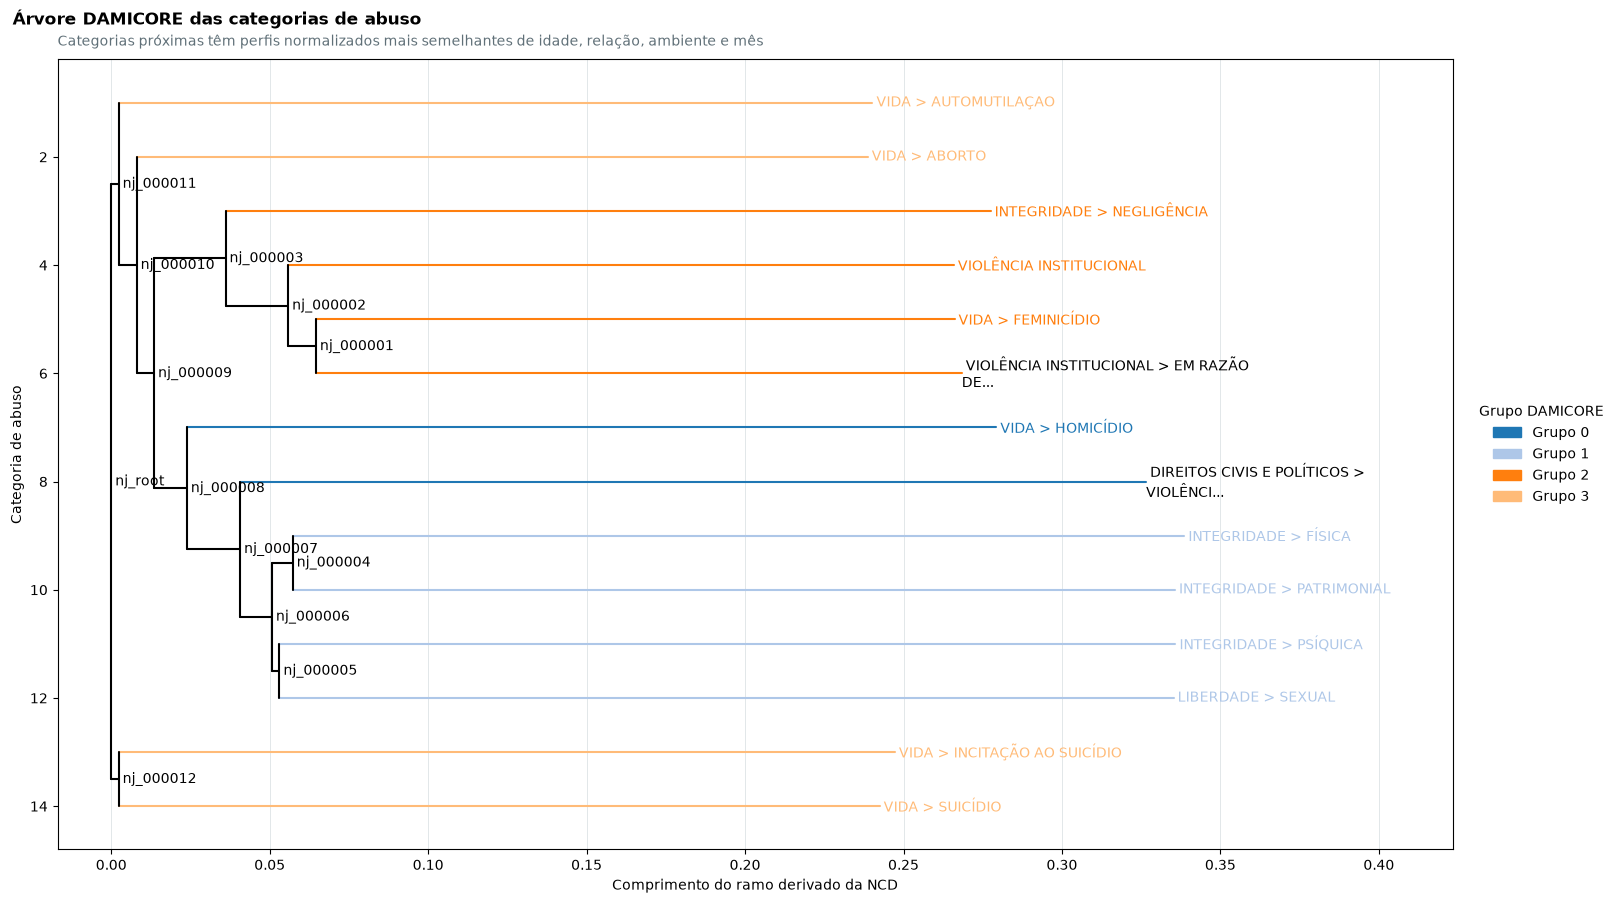

In [6]:
tree = Phylo.read(StringIO(tree_newick), "newick")
by_object_id = category_clusters.set_index("object_id")
by_label = category_clusters.set_index("label")
label_colors = {}

for terminal in tree.get_terminals():
    if terminal.name in by_object_id.index:
        category_row = by_object_id.loc[terminal.name]
    elif terminal.name in by_label.index:
        category_row = by_label.loc[terminal.name]
    else:
        raise KeyError(f"Folha desconhecida na árvore DAMICORE: {terminal.name}")
    cluster = int(category_row["cluster"])
    terminal.name = wrapped_label(category_row["category"], width=35)
    terminal.color = cluster_hex_colors[cluster]
    label_colors[terminal.name] = cluster_hex_colors[cluster]

figure_height = max(10, len(category_clusters) * 0.34)
figure, axis = plt.subplots(figsize=(18, figure_height))
Phylo.draw(
    tree,
    axes=axis,
    do_show=False,
    show_confidence=False,
    label_colors=label_colors,
)
figure.subplots_adjust(top=0.9)
figure.suptitle("Árvore DAMICORE das categorias de abuso", x=0.1, y=0.95, ha="left", weight="bold")
axis.set_title(
    "Categorias próximas têm perfis normalizados mais semelhantes de idade, relação, ambiente e mês",
    loc="left", color="#607078", fontsize=10, pad=10,
)
axis.set_xlabel("Comprimento do ramo derivado da NCD")
axis.set_ylabel("Categoria de abuso")
axis.margins(y=0.05)
axis.legend(
    handles=[Patch(color=cluster_hex_colors[cluster], label=f"Grupo {cluster}") for cluster in clusters],
    title="Grupo DAMICORE", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False,
)
axis.grid(axis="x", color="#E2E7E9", linewidth=0.7)
figure.savefig(RESULTS_DIR / "category-tree.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 6. Grafo 1 — cluster DAMICORE e categoria de abuso

Cada aresta vem diretamente da associação DAMICORE. Nós de categoria maiores e arestas mais espessas indicam mais denúncias distintas.


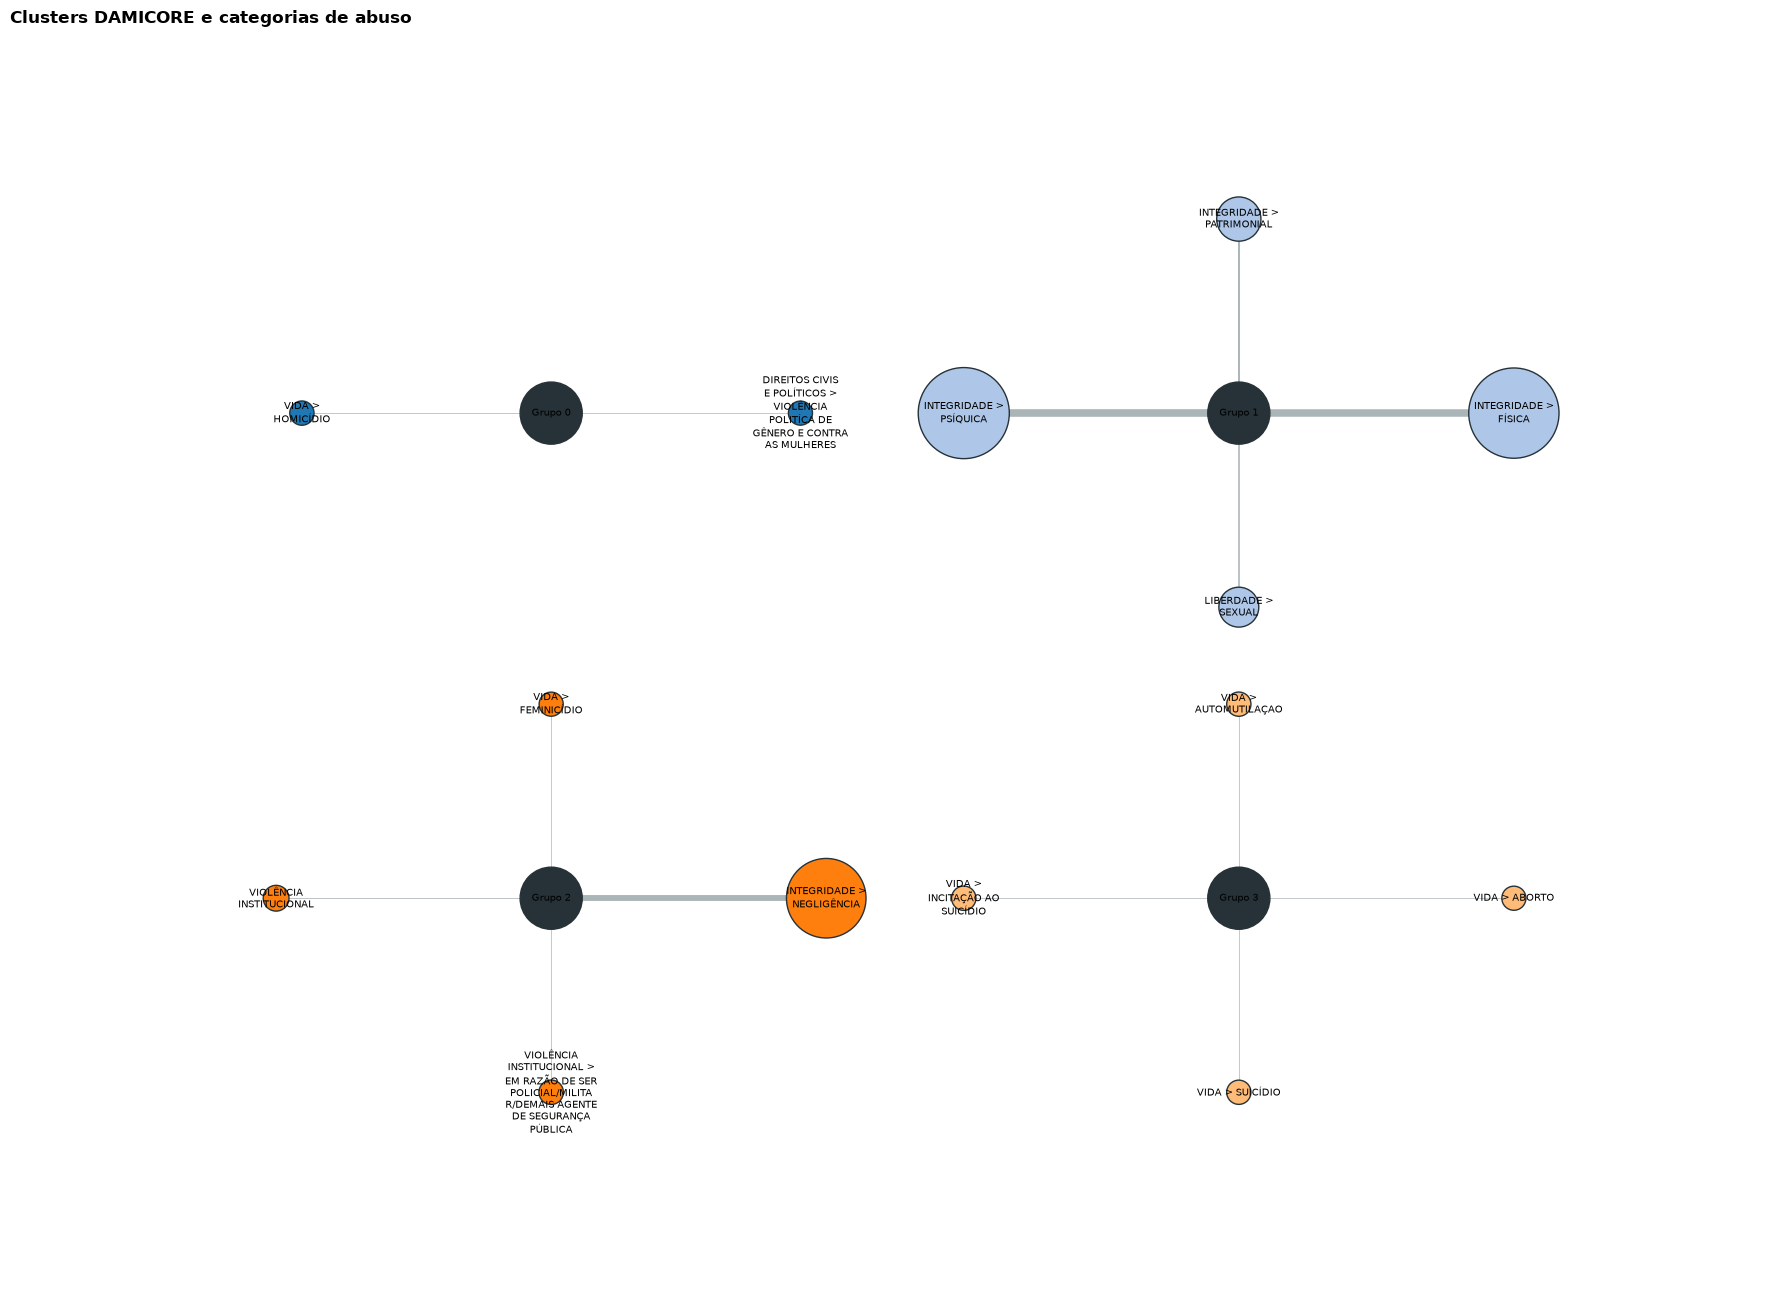

In [7]:
cluster_graph = nx.Graph(experiment="DAMICORE categorias de abuso 2020 a 2026")
for row in category_clusters.itertuples(index=False):
    cluster_node = f"cluster:{row.cluster}"
    category_node = f"category:{row.label}"
    cluster_graph.add_node(cluster_node, node_type="cluster", label=f"Grupo {row.cluster}")
    cluster_graph.add_node(
        category_node, node_type="category", label=row.category,
        cluster=int(row.cluster), report_count=int(row.report_count),
    )
    cluster_graph.add_edge(cluster_node, category_node, report_count=int(row.report_count))

for cluster in category_clusters["cluster"].unique():
    node = f"cluster:{cluster}"
    cluster_graph.nodes[node]["report_count"] = int(
        category_clusters.loc[category_clusters["cluster"] == cluster, "report_count"].sum()
    )

nx.write_graphml(cluster_graph, RESULTS_DIR / "category-clusters.graphml")

max_support = category_clusters["report_count"].max()
positions = {}
cluster_nodes = sorted(
    (node for node, data in cluster_graph.nodes(data=True) if data["node_type"] == "cluster"),
    key=lambda node: int(node.split(":", maxsplit=1)[1]),
)
grid_columns = ceil(sqrt(len(cluster_nodes)))
grid_rows = ceil(len(cluster_nodes) / grid_columns)
component_spacing = 8.0
for index, cluster_node in enumerate(cluster_nodes):
    row, column = divmod(index, grid_columns)
    center_x = (column - (grid_columns - 1) / 2) * component_spacing
    center_y = ((grid_rows - 1) / 2 - row) * component_spacing
    positions[cluster_node] = (center_x, center_y)
    neighbors = sorted(cluster_graph.neighbors(cluster_node))
    for neighbor_index, category_node in enumerate(neighbors):
        angle = 2 * pi * neighbor_index / len(neighbors)
        radius = 2.6 + 0.15 * len(neighbors)
        positions[category_node] = (
            center_x + radius * cos(angle),
            center_y + radius * sin(angle),
        )

node_sizes = [
    2000 if data["node_type"] == "cluster" else 300 + 4000 * data["report_count"] / max_support
    for _, data in cluster_graph.nodes(data=True)
]
node_colors = [
    VISUAL_STYLE['node_border_color'] if data["node_type"] == "cluster" else cluster_colors[data["cluster"]]
    for _, data in cluster_graph.nodes(data=True)
]
edge_widths = [0.5 + 5 * data["report_count"] / max_support for _, _, data in cluster_graph.edges(data=True)]
labels = {node: wrapped_label(data["label"], width=15) for node, data in cluster_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx_nodes(
    cluster_graph, positions, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    edgecolors=VISUAL_STYLE['node_border_color'], linewidths=VISUAL_STYLE['border_width']
)
nx.draw_networkx_edges(
    cluster_graph, positions, ax=axis,
    width=edge_widths, edge_color=VISUAL_STYLE['edge_color_cluster']
)
nx.draw_networkx_labels(
    cluster_graph, positions, labels=labels, ax=axis,
    font_size=VISUAL_STYLE['font_size']
)
axis.margins(0.15)
axis.set_title("Clusters DAMICORE e categorias de abuso", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-clusters.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 7. Grafo 2 — duas categorias mais próximas pela NCD

Cada categoria se liga às duas menores distâncias que não são dela mesma. A espessura da aresta representa `1 / (1 + NCD)`; arestas mais espessas indicam maior semelhança.


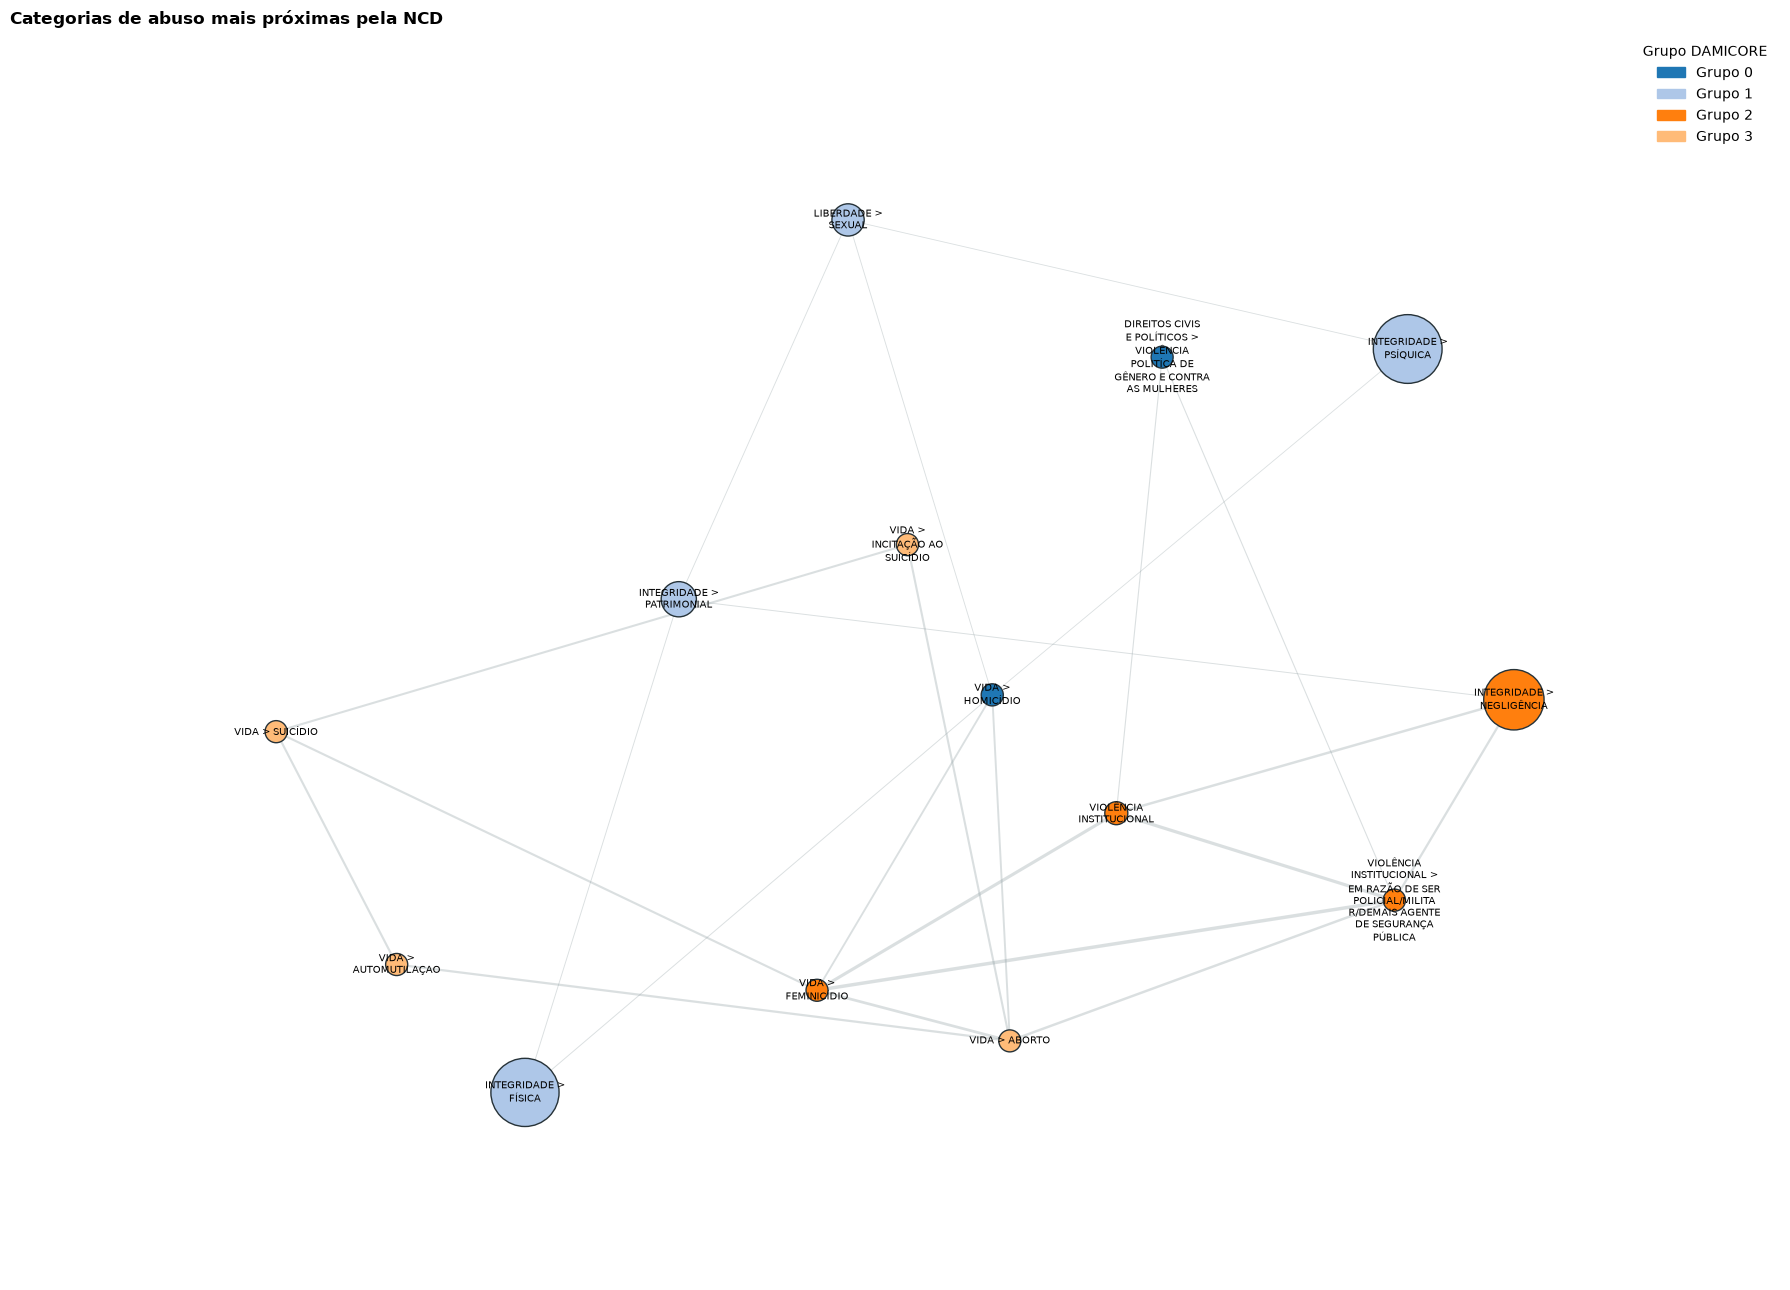

In [8]:
similarity_graph = nx.Graph(experiment="DAMICORE semelhança entre categorias 2020 a 2026")
cluster_by_label = category_clusters.set_index("label")

for label, row in cluster_by_label.iterrows():
    similarity_graph.add_node(
        label, node_type="category", label=row["category"],
        cluster=int(row["cluster"]), report_count=int(row["report_count"]),
    )

for label in distance_matrix.index:
    for neighbor, ncd in distance_matrix.loc[label].drop(label).nsmallest(2).items():
        ncd = float(ncd)
        if not similarity_graph.has_edge(label, neighbor) or ncd < similarity_graph[label][neighbor]["ncd_distance"]:
            similarity_graph.add_edge(
                label, neighbor, ncd_distance=ncd, similarity=1.0 / (1.0 + ncd)
            )

nx.write_graphml(similarity_graph, RESULTS_DIR / "category-similarity.graphml")

positions = nx.spring_layout(similarity_graph, seed=42, weight="similarity", k=1.2)
node_sizes = [
    250 + 2200 * data["report_count"] / max_support
    for _, data in similarity_graph.nodes(data=True)
]
node_colors = [cluster_colors[data["cluster"]] for _, data in similarity_graph.nodes(data=True)]
similarity_values = [data["similarity"] for _, _, data in similarity_graph.edges(data=True)]
similarity_min = min(similarity_values)
similarity_span = max(similarity_values) - similarity_min
edge_widths = [
    1.5 if similarity_span == 0 else 0.6 + 1.9 * (value - similarity_min) / similarity_span
    for value in similarity_values
]
labels = {node: wrapped_label(data["label"], width=15) for node, data in similarity_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx_nodes(
    similarity_graph, positions, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    edgecolors=VISUAL_STYLE['node_border_color'], linewidths=VISUAL_STYLE['border_width']
)
nx.draw_networkx_edges(
    similarity_graph, positions, ax=axis,
    width=edge_widths, edge_color=VISUAL_STYLE['edge_color_sim'], alpha=0.3
)
nx.draw_networkx_labels(
    similarity_graph, positions, labels=labels, ax=axis,
    font_size=VISUAL_STYLE['font_size']
)
axis.margins(0.15)
axis.set_title("Categorias de abuso mais próximas pela NCD", loc="left", weight="bold")
axis.legend(
    handles=[Patch(color=cluster_hex_colors[cluster], label=f"Grupo {cluster}") for cluster in clusters],
    title="Grupo DAMICORE", loc="upper right", bbox_to_anchor=(1, 1), frameon=False,
)
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-similarity.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## Limite de interpretação

O DAMICORE agrupa categorias elegíveis da fonte cujos desvios relativos de contexto demográfico, do processo de registro, da relação, do ambiente e do mês são comprimidos de forma semelhante. Interprete a árvore e os grafos somente quando o diagnóstico de viés for aceitável. Mesmo assim, os clusters são perfis contextuais exploratórios, não tipologias jurídicas ou sociais confirmadas de abuso; as categorias esparsas excluídas precisam de uma análise descritiva separada.
